# Trial-wise responses analysis

- [x] LMM: linear mixed-effects model
- [x] Pairwise comparisons with emmeans + effect size
- [x] Residual diagnostics
- [ ] Acceptance: cumulative link mixed model

In [5]:
library(tidyverse)   # read_csv, dplyr, ggplot2, etc.
library(lme4)        # lmer()
library(lmerTest)    # p-values for LMM
library(emmeans)     # post hoc comparisons
library(effectsize)  # effect sizes
library(performance) # model diagnostics

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [7]:
# Response variables analysed using LMM
li_resp_LMM <- c("SoA")
# Single ordinal response analysed using CLMM
li_resp_CLMM <- c("Accept", "Authorship")

long <- read_csv(
  "data_analysis/trial_wise_SoA_cleaned_long.csv",
  show_col_types = FALSE
)
wide <- read_csv(
  "data_analysis/trial_wise_SoA_with_pp_traits.csv",
  show_col_types = FALSE
)

In [8]:
head(wide, 3)

pp,trial,voice_id,condition,scene_id,1,2,3,4,5,⋯,8,9,ans_sd,SoPA,SoNA,Accept,SoA,Authorship,AI_literacy_z,DoC_z
<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
P01,1,clone,repeat,1,4,6,1,4,2,⋯,2,3,1.752549,2.8,4.5,3,3.000000,4,1.370731,-0.06454751
P01,2,clone,enhance,3,2,2,3,2,1,⋯,3,7,1.832251,2.0,5.5,7,2.142857,2,1.370731,-0.06454751
P01,3,clone,counter,5,1,2,2,1,2,⋯,3,4,2.375470,1.6,6.0,4,1.714286,1,1.370731,-0.06454751


# main LMM
SoA ~ condition * voice_id + AI_literacy_z + DoC_z + (1 | pp)

In [9]:
# fit lmm model for SoA
lmm_SoA <- lmer(
  SoA ~ condition * voice_id + AI_literacy_z + DoC_z + (1 | pp),
  data = wide
)
summary(lmm_SoA)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: SoA ~ condition * voice_id + AI_literacy_z + DoC_z + (1 | pp)
   Data: wide

REML criterion at convergence: 1017.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.09063 -0.70575 -0.01297  0.63031  2.91031 

Random effects:
 Groups   Name        Variance Std.Dev.
 pp       (Intercept) 0.5534   0.7439  
 Residual             1.1061   1.0517  
Number of obs: 326, groups:  pp, 28

Fixed effects:
                                  Estimate Std. Error        df t value
(Intercept)                        2.47449    0.19878  70.19943  12.448
conditionenhance                   0.94643    0.19875 293.17229   4.762
conditionrepeat                    1.93251    0.19975 293.26386   9.675
voice_idrobotic                   -0.11480    0.19875 293.17229  -0.578
AI_literacy_z                     -0.07571    0.15917  25.50896  -0.476
DoC_z                              0.29414    0.15930  25

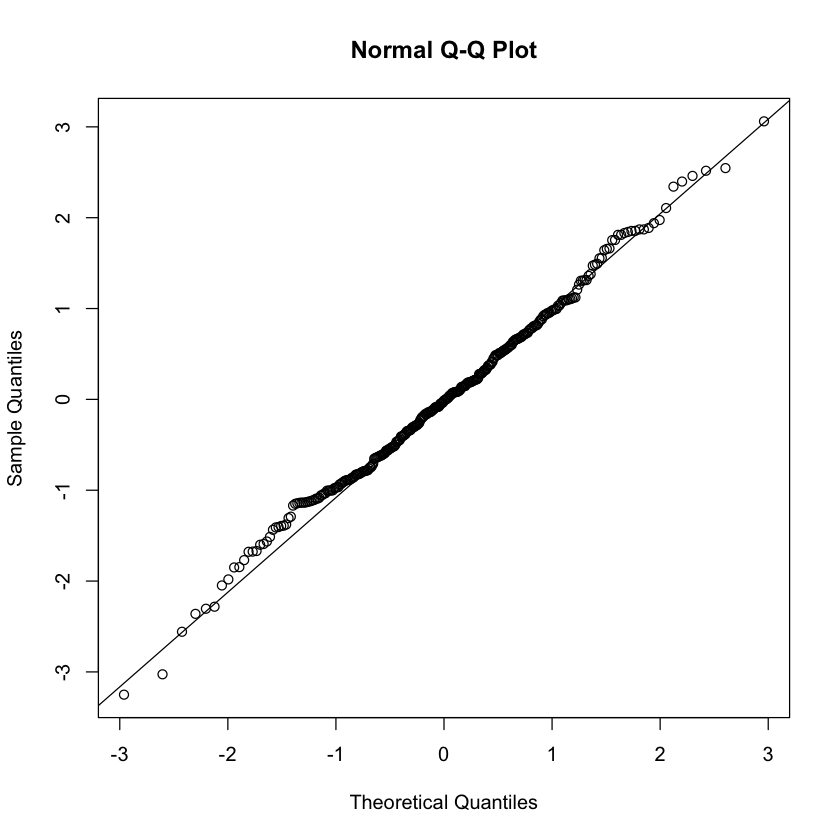

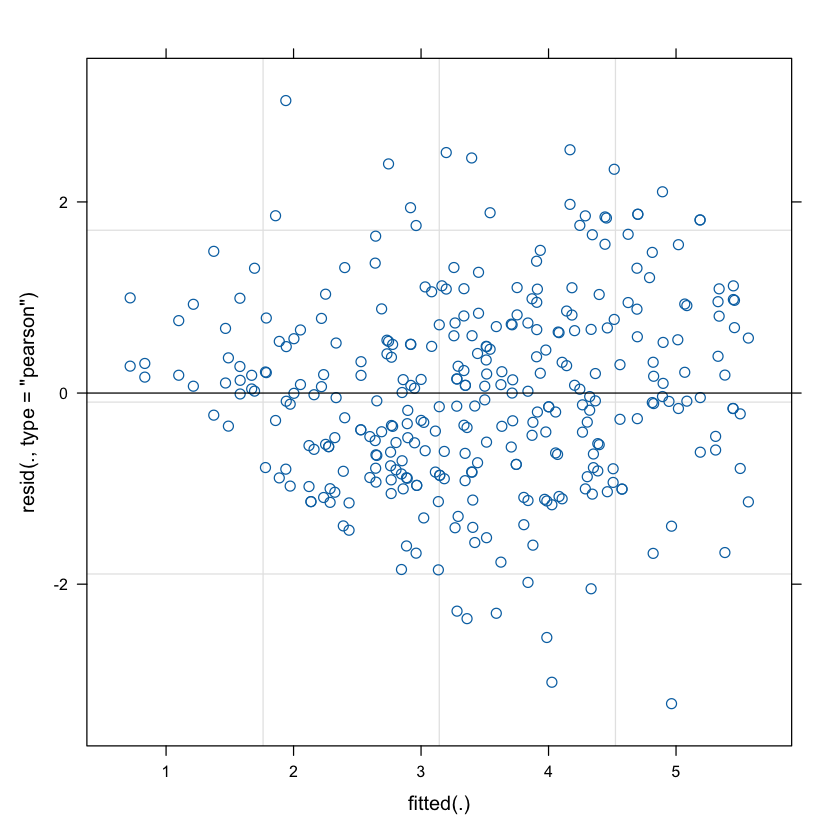

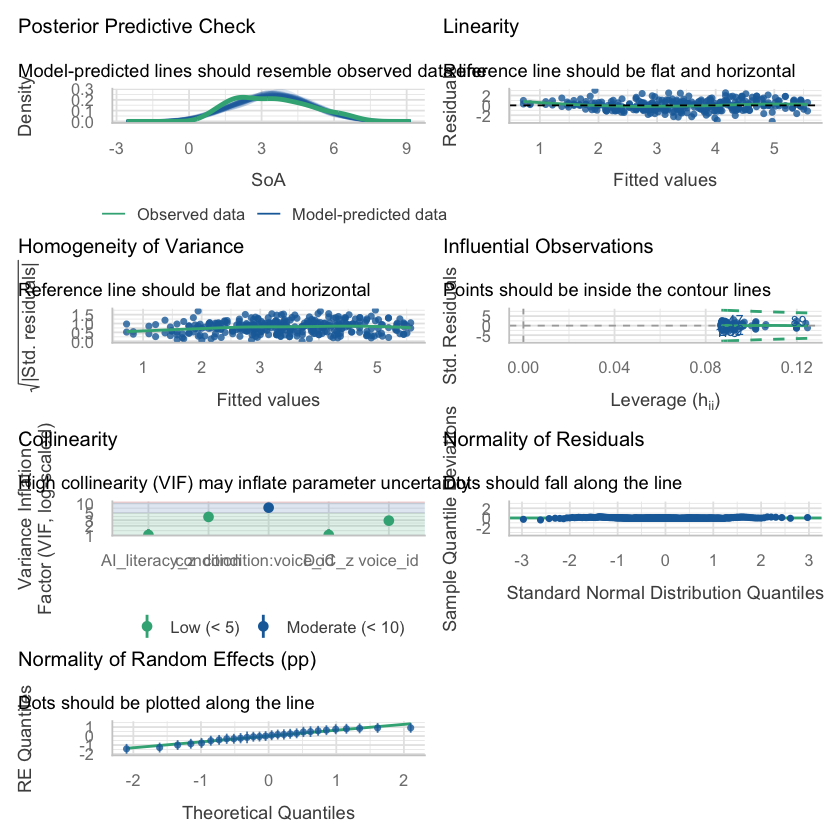

In [13]:
# performance check: check residuals
qqnorm(resid(lmm_SoA))
qqline(resid(lmm_SoA))

plot(lmm_SoA)

performance::check_model(lmm_SoA)

In [14]:
# omnibus test for SoA / hypothesis testing for SoA
anova(lmm_SoA, type = 3)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F)
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
condition,228.0881034,114.0440517,2,293.50861,103.1067643,1.213231e-34
voice_id,0.2561271,0.2561271,1,293.48405,0.2315635,6.307255e-01
AI_literacy_z,0.2502475,0.2502475,1,25.50896,0.2262477,6.383683e-01
DoC_z,3.7710094,3.7710094,1,25.58447,3.4093543,7.642781e-02
condition:voice_id,1.2331292,0.6165646,2,293.32933,0.5574335,5.732824e-01


In [28]:
# pairwise comparision
emm <- emmeans(lmm_SoA, pairwise ~ condition | voice_id)
pairs(emm, adjust = "holm")
eff_size(
    emm,
    sigma = sigma(lmm_SoA),
    edf = df.residual(lmm_SoA)
)

voice_id = clone:
 contrast          estimate    SE  df t.ratio p.value
 counter - enhance   -0.946 0.199 293  -4.762 <0.0001
 counter - repeat    -1.933 0.200 293  -9.675 <0.0001
 enhance - repeat    -0.986 0.200 293  -4.937 <0.0001

voice_id = robotic:
 contrast          estimate    SE  df t.ratio p.value
 counter - enhance   -1.224 0.203 293  -6.036 <0.0001
 counter - repeat    -2.168 0.204 294 -10.616 <0.0001
 enhance - repeat    -0.943 0.208 293  -4.541 <0.0001

Degrees-of-freedom method: kenward-roger 
P value adjustment: holm method for 3 tests 

Since 'object' is a list, we are using the contrasts already present.



voice_id = clone:
 contrast            effect.size    SE  df lower.CL upper.CL
 (counter - enhance)      -0.900 0.192 293    -1.28   -0.521
 (counter - repeat)       -1.838 0.204 293    -2.24   -1.437
 (enhance - repeat)       -0.938 0.194 293    -1.32   -0.557

voice_id = robotic:
 contrast            effect.size    SE  df lower.CL upper.CL
 (counter - enhance)      -1.164 0.198 293    -1.55   -0.774
 (counter - repeat)       -2.061 0.211 294    -2.48   -1.646
 (enhance - repeat)       -0.897 0.201 293    -1.29   -0.502

sigma used for effect sizes: 1.052 
Degrees-of-freedom method: inherited from kenward-roger when re-gridding 
Confidence level used: 0.95 

In [29]:
# pairwise comparisons for SoA
emm <- emmeans(lmm_SoA, pairwise ~ voice_id | condition)
pairs(emm, adjust = "holm")
eff_size(
    emm,
    sigma = sigma(lmm_SoA),
    edf = df.residual(lmm_SoA)
)

condition = counter:
 contrast        estimate    SE  df t.ratio p.value
 clone - robotic    0.115 0.199 293   0.578  0.5640

condition = enhance:
 contrast        estimate    SE  df t.ratio p.value
 clone - robotic   -0.163 0.203 293  -0.804  0.4218

condition = repeat:
 contrast        estimate    SE  df t.ratio p.value
 clone - robotic   -0.120 0.205 293  -0.587  0.5577

Degrees-of-freedom method: kenward-roger 

Since 'object' is a list, we are using the contrasts already present.



condition = counter:
 contrast          effect.size    SE  df lower.CL upper.CL
 (clone - robotic)       0.109 0.189 293   -0.263    0.481

condition = enhance:
 contrast          effect.size    SE  df lower.CL upper.CL
 (clone - robotic)      -0.155 0.193 293   -0.535    0.225

condition = repeat:
 contrast          effect.size    SE  df lower.CL upper.CL
 (clone - robotic)      -0.114 0.195 293   -0.498    0.269

sigma used for effect sizes: 1.052 
Degrees-of-freedom method: inherited from kenward-roger when re-gridding 
Confidence level used: 0.95 

In [21]:
# effect size for SoA
# partial η² - the proportion of variance explained by a given effect, partialling out other effects from the total non-error variance
eta_squared(lmm_SoA, partial = TRUE)

# marginal R² - the proportion of variance explained by the fixed effects alone
r2(lmm_SoA)

Parameter,Eta2_partial,CI,CI_low,CI_high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
condition,0.4126563803,0.95,0.3437643,1
voice_id,0.0007883934,0.95,0.0000000,1
AI_literacy_z,0.0087913703,0.95,0.0000000,1
DoC_z,0.1175889866,0.95,0.0000000,1
condition:voice_id,0.0037863443,0.95,0.0000000,1


# R2 for Mixed Models

  Conditional R2: 0.545
     Marginal R2: 0.318